In [1]:
import requests
import pandas as pd
import numpy as np
import io
import time
import warnings
warnings.filterwarnings('ignore')

# Fetch merged gameweek data from vaastav
seasons = [
    '2016-17','2017-18','2018-19','2019-20',
    '2020-21','2021-22','2022-23','2023-24'
]

base = 'https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data'
all_gw = []

for season in seasons:
    url = f'{base}/{season}/gws/merged_gw.csv'
    try:
        r = requests.get(url, timeout=30)
        if r.status_code == 200:
            df_s = pd.read_csv(io.StringIO(r.text))
            df_s['season_name'] = season[:4] + '/' + season[-2:]
            all_gw.append(df_s)
            print(f'✓ {season}: {len(df_s)} gameweek records')
        else:
            print(f'✗ {season}: status {r.status_code}')
    except Exception as e:
        print(f'✗ {season}: {e}')
    time.sleep(0.3)

gw_df = pd.concat(all_gw, ignore_index=True)
print(f'\nTotal gameweek records: {len(gw_df)}')
print(f'Columns: {list(gw_df.columns)}')

✓ 2016-17: 23679 gameweek records
✓ 2017-18: 22467 gameweek records
✓ 2018-19: 21790 gameweek records
✓ 2019-20: 22560 gameweek records
✓ 2020-21: 24365 gameweek records
✓ 2021-22: 25447 gameweek records
✓ 2022-23: 26505 gameweek records
✓ 2023-24: 29725 gameweek records

Total gameweek records: 196538
Columns: ['name', 'assists', 'attempted_passes', 'big_chances_created', 'big_chances_missed', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'completed_passes', 'creativity', 'dribbles', 'ea_index', 'element', 'errors_leading_to_goal', 'errors_leading_to_goal_attempt', 'fixture', 'fouls', 'goals_conceded', 'goals_scored', 'ict_index', 'id', 'influence', 'key_passes', 'kickoff_time', 'kickoff_time_formatted', 'loaned_in', 'loaned_out', 'minutes', 'offside', 'open_play_crosses', 'opponent_team', 'own_goals', 'penalties_conceded', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'round', 'saves', 'selected', 'tackled', 'tackles', 'target_missed', 'team_a

In [2]:
# ── Clean and prep gameweek data ──────────────────────────────────────
season_order = {
    '2016/17':1,'2017/18':2,'2018/19':3,'2019/20':4,
    '2020/21':5,'2021/22':6,'2022/23':7,'2023/24':8
}

gw_df['season_num'] = gw_df['season_name'].map(season_order)

# Convert xG cols to numeric
xg_cols = ['expected_goals','expected_assists',
           'expected_goal_involvements','expected_goals_conceded']
for col in xg_cols:
    if col in gw_df.columns:
        gw_df[col] = pd.to_numeric(gw_df[col], errors='coerce').fillna(0)

# Price in millions
gw_df['price'] = gw_df['value'] / 10

# Home/away flag
gw_df['home_flag'] = gw_df['was_home'].astype(int)

# Team goals scored and conceded from match scores
gw_df['team_goals_scored']   = np.where(gw_df['was_home'],
                                          gw_df['team_h_score'],
                                          gw_df['team_a_score'])
gw_df['team_goals_conceded'] = np.where(gw_df['was_home'],
                                          gw_df['team_a_score'],
                                          gw_df['team_h_score'])

# Sort for rolling features
gw_df = gw_df.sort_values(['element','season_num','GW']).reset_index(drop=True)

# Create global gameweek index for correct temporal ordering
gw_df['global_gw'] = (gw_df['season_num'] - 1) * 38 + gw_df['GW']

print(f'Records: {len(gw_df)}')
print(f'Unique players: {gw_df["element"].nunique()}')
print(f'Seasons: {sorted(gw_df["season_name"].unique())}')
print(f'Positions: {gw_df["position"].value_counts().to_dict()}')
print(gw_df[["name","season_name","GW","total_points","price","home_flag"]].head(10))

Records: 196538
Unique players: 866
Seasons: ['2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24']
Positions: {'MID': 44642, 'DEF': 36040, 'FWD': 13478, 'GK': 11781, 'GKP': 101}
           name season_name  GW  total_points  price  home_flag
0  David_Ospina     2016/17   1             0    5.0          1
1  David_Ospina     2016/17   2             0    5.0          0
2  David_Ospina     2016/17   3             0    5.0          0
3  David_Ospina     2016/17   4             0    4.9          1
4  David_Ospina     2016/17   5             0    4.9          0
5  David_Ospina     2016/17   6             0    4.9          1
6  David_Ospina     2016/17   7             0    4.9          0
7  David_Ospina     2016/17   8             0    4.9          1
8  David_Ospina     2016/17   9             0    4.8          1
9  David_Ospina     2016/17  10             0    4.8          0


In [3]:
# Fix position names
gw_df['position'] = gw_df['position'].replace('GK', 'GKP')

# Position encoding
pos_dummies = pd.get_dummies(gw_df['position'], prefix='pos')
gw_df = pd.concat([gw_df, pos_dummies], axis=1)
for col in ['pos_GKP','pos_DEF','pos_MID','pos_FWD']:
    if col in gw_df.columns:
        gw_df[col] = gw_df[col].astype(int)
    else:
        gw_df[col] = 0

print('Position fix done.')
print(gw_df['position'].value_counts())

# ── Rolling features (all shifted by 1 GW to prevent leakage) ────────
roll_cols = ['total_points','minutes','goals_scored','assists',
             'clean_sheets','bonus','saves','goals_conceded',
             'expected_goals','expected_assists',
             'expected_goal_involvements','team_goals_scored',
             'team_goals_conceded','bps','threat','creativity',
             'influence','ict_index']

# Only use cols that exist
roll_cols = [c for c in roll_cols if c in gw_df.columns]

print(f'\nBuilding rolling features for {len(roll_cols)} columns...')

for col in roll_cols:
    # Shift by 1 first to avoid leakage (only past GWs used)
    shifted = gw_df.groupby('element')[col].shift(1)
    gw_df[f'{col}_roll3']  = shifted.groupby(gw_df['element']).transform(
        lambda x: x.rolling(3,  min_periods=1).mean())
    gw_df[f'{col}_roll5']  = shifted.groupby(gw_df['element']).transform(
        lambda x: x.rolling(5,  min_periods=1).mean())
    gw_df[f'{col}_lag1']   = shifted

print('Rolling features built.')

# Naive baseline: last 3 GW average points
gw_df['baseline_pred'] = gw_df['total_points_roll3']

print(f'\nSample rolling features:')
print(gw_df[['name','season_name','GW','total_points',
             'total_points_lag1','total_points_roll3',
             'total_points_roll5']].head(10))

Position fix done.
position
MID    44642
DEF    36040
FWD    13478
GKP    11882
Name: count, dtype: int64

Building rolling features for 18 columns...
Rolling features built.

Sample rolling features:
           name season_name  GW  total_points  total_points_lag1  \
0  David_Ospina     2016/17   1             0                NaN   
1  David_Ospina     2016/17   2             0                0.0   
2  David_Ospina     2016/17   3             0                0.0   
3  David_Ospina     2016/17   4             0                0.0   
4  David_Ospina     2016/17   5             0                0.0   
5  David_Ospina     2016/17   6             0                0.0   
6  David_Ospina     2016/17   7             0                0.0   
7  David_Ospina     2016/17   8             0                0.0   
8  David_Ospina     2016/17   9             0                0.0   
9  David_Ospina     2016/17  10             0                0.0   

   total_points_roll3  total_points_roll5  
0     

In [4]:
# ── Build feature matrix ──────────────────────────────────────────────
feature_cols_gw = (
    [f'{c}_roll3' for c in roll_cols] +
    [f'{c}_roll5' for c in roll_cols] +
    [f'{c}_lag1'  for c in roll_cols] +
    ['home_flag', 'price', 'season_num', 'GW',
     'pos_GKP','pos_DEF','pos_MID','pos_FWD']
)
feature_cols_gw = [c for c in feature_cols_gw if c in gw_df.columns]

target_gw = 'total_points'

# Drop rows with NaN in features
df_gw = gw_df[feature_cols_gw + [target_gw, 'season_name', 'season_num',
                                   'element', 'name', 'position',
                                   'GW', 'baseline_pred']].dropna()

print(f'Total samples:  {len(df_gw)}')
print(f'Features:       {len(feature_cols_gw)}')
print(f'Seasons:        {sorted(df_gw["season_name"].unique())}')
print(f'Target mean:    {df_gw[target_gw].mean():.2f}')
print(f'Target std:     {df_gw[target_gw].std():.2f}')
print(f'Target max:     {df_gw[target_gw].max():.0f}')

Total samples:  105859
Features:       62
Seasons:        ['2020/21', '2021/22', '2022/23', '2023/24']
Target mean:    1.19
Target std:     2.39
Target max:     26


In [5]:
# ── Train/test split ──────────────────────────────────────────────────
# Test on 2023/24, train on 2020/21 to 2022/23
train_gw = df_gw[df_gw['season_name'] != '2023/24']
test_gw  = df_gw[df_gw['season_name'] == '2023/24']

X_train_gw = train_gw[feature_cols_gw].values
y_train_gw = train_gw[target_gw].values
X_test_gw  = test_gw[feature_cols_gw].values
y_test_gw  = test_gw[target_gw].values

# Scale
scaler_gw = StandardScaler()
X_train_gw_s = scaler_gw.fit_transform(X_train_gw)
X_test_gw_s  = scaler_gw.transform(X_test_gw)

print(f'Train: {X_train_gw.shape}')
print(f'Test:  {X_test_gw.shape}')

# Naive baseline
y_base_gw = test_gw['baseline_pred'].values
y_base_gw = np.nan_to_num(y_base_gw, nan=df_gw[target_gw].mean())

# ── Ridge ─────────────────────────────────────────────────────────────
from sklearn.linear_model import RidgeCV
ridge_gw = RidgeCV(alphas=[0.1,1.0,10.0,100.0], cv=5)
ridge_gw.fit(X_train_gw_s, y_train_gw)
y_ridge_gw = ridge_gw.predict(X_test_gw_s)
print(f'Ridge alpha: {ridge_gw.alpha_}')

# ── XGBoost ───────────────────────────────────────────────────────────
xgb_gw = XGBRegressor(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbosity=0
)
xgb_gw.fit(X_train_gw, y_train_gw)
y_xgb_gw = xgb_gw.predict(X_test_gw)
print('XGBoost trained.')

# ── Neural Network ────────────────────────────────────────────────────
tf.random.set_seed(42)
nn_gw = keras.Sequential([
    layers.Input(shape=(X_train_gw_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
nn_gw.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
es_gw = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                        restore_best_weights=True)
nn_gw.fit(X_train_gw_s, y_train_gw,
          validation_split=0.15,
          epochs=100,
          batch_size=512,
          callbacks=[es_gw],
          verbose=1)
y_nn_gw = nn_gw.predict(X_test_gw_s).flatten()
print('Neural Network trained.')

NameError: name 'StandardScaler' is not defined

In [6]:
import requests
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
from xgboost import XGBRegressor
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pulp

# ── Train/test split ──────────────────────────────────────────────────
train_gw = df_gw[df_gw['season_name'] != '2023/24']
test_gw  = df_gw[df_gw['season_name'] == '2023/24']

X_train_gw = train_gw[feature_cols_gw].values
y_train_gw = train_gw[target_gw].values
X_test_gw  = test_gw[feature_cols_gw].values
y_test_gw  = test_gw[target_gw].values

scaler_gw = StandardScaler()
X_train_gw_s = scaler_gw.fit_transform(X_train_gw)
X_test_gw_s  = scaler_gw.transform(X_test_gw)

print(f'Train: {X_train_gw.shape}')
print(f'Test:  {X_test_gw.shape}')

y_base_gw = test_gw['baseline_pred'].values
y_base_gw = np.nan_to_num(y_base_gw, nan=df_gw[target_gw].mean())

# Ridge
ridge_gw = RidgeCV(alphas=[0.1,1.0,10.0,100.0], cv=5)
ridge_gw.fit(X_train_gw_s, y_train_gw)
y_ridge_gw = ridge_gw.predict(X_test_gw_s)
print(f'Ridge alpha: {ridge_gw.alpha_}')

# XGBoost
xgb_gw = XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_alpha=0.5, reg_lambda=2.0, random_state=42, verbosity=0
)
xgb_gw.fit(X_train_gw, y_train_gw)
y_xgb_gw = xgb_gw.predict(X_test_gw)
print('XGBoost trained.')

# Neural Network
tf.random.set_seed(42)
nn_gw = keras.Sequential([
    layers.Input(shape=(X_train_gw_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
nn_gw.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
es_gw = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                        restore_best_weights=True)
nn_gw.fit(X_train_gw_s, y_train_gw,
          validation_split=0.15, epochs=100, batch_size=512,
          callbacks=[es_gw], verbose=1)
y_nn_gw = nn_gw.predict(X_test_gw_s).flatten()
print('Neural Network trained.')


Train: (76222, 64)
Test:  (29637, 64)
Ridge alpha: 100.0
XGBoost trained.

Epoch 1/100


127/127 [==============================] - 5s 17ms/step - loss: 5.2805 - mae: 1.3456 - val_loss: 1.9743 - val_mae: 0.5183
Epoch 2/100
127/127 [==============================] - 2s 13ms/step - loss: 4.8316 - mae: 1.2652 - val_loss: 1.8560 - val_mae: 0.5289
Epoch 3/100
127/127 [==============================] - 1s 12ms/step - loss: 4.7575 - mae: 1.2477 - val_loss: 1.8359 - val_mae: 0.5233
Epoch 4/100
127/127 [==============================] - 2s 16ms/step - loss: 4.7240 - mae: 1.2428 - val_loss: 1.8295 - val_mae: 0.5293
Epoch 5/100
127/127 [==============================] - 2s 14ms/step - loss: 4.7005 - mae: 1.2344 - val_loss: 1.8262 - val_mae: 0.5223
Epoch 6/100
127/127 [==============================] - 2s 15ms/step - loss: 4.6774 - mae: 1.2294 - val_loss: 1.8219 - val_mae: 0.5228
Epoch 7/100
127/127 [==============================] - 2s 15ms/step - loss: 4.6554 - mae: 1.2275 - val_loss: 1.8154 - 

In [7]:
# ── Compute all metrics including Spearman rank correlation ───────────
from scipy.stats import spearmanr

def get_metrics_gw(y_true, y_pred, label):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    spearman = spearmanr(y_true, y_pred).correlation
    return {
        'Model': label,
        'R2':       round(r2, 3),
        'MAE':      round(mae, 3),
        'RMSE':     round(rmse, 3),
        'Spearman': round(spearman, 3)
    }

# Ensembles
y_xgb_nn_gw      = (y_xgb_gw + y_nn_gw) / 2
y_ridge_xgb_gw   = (y_ridge_gw + y_xgb_gw) / 2
y_ridge_xgb_nn_gw = (y_ridge_gw + y_xgb_gw + y_nn_gw) / 3

results_gw = pd.DataFrame([
    get_metrics_gw(y_test_gw, y_base_gw,         'Baseline (last 3 GW avg)'),
    get_metrics_gw(y_test_gw, y_ridge_gw,         'Ridge Regression'),
    get_metrics_gw(y_test_gw, y_xgb_gw,           'XGBoost'),
    get_metrics_gw(y_test_gw, y_nn_gw,            'Neural Network'),
    get_metrics_gw(y_test_gw, y_xgb_nn_gw,        'Ensemble: XGB + NN'),
    get_metrics_gw(y_test_gw, y_ridge_xgb_gw,     'Ensemble: Ridge + XGB'),
    get_metrics_gw(y_test_gw, y_ridge_xgb_nn_gw,  'Ensemble: Ridge + XGB + NN'),
])

print('=== GAMEWEEK MODEL RESULTS (2023/24 test season) ===')
print(results_gw.to_string(index=False))

best_gw = results_gw.loc[results_gw['R2'].idxmax()]
print(f'\nBest model: {best_gw["Model"]} (R2={best_gw["R2"]}, Spearman={best_gw["Spearman"]})')

=== GAMEWEEK MODEL RESULTS (2023/24 test season) ===
                     Model    R2   MAE  RMSE  Spearman
  Baseline (last 3 GW avg) 0.116 1.035 2.159     0.665
          Ridge Regression 0.289 1.015 1.936     0.662
                   XGBoost 0.294 0.970 1.930     0.682
            Neural Network 0.284 0.946 1.942     0.662
        Ensemble: XGB + NN 0.296 0.953 1.926     0.679
     Ensemble: Ridge + XGB 0.297 0.988 1.925     0.677
Ensemble: Ridge + XGB + NN 0.297 0.971 1.925     0.678

Best model: Ensemble: Ridge + XGB (R2=0.297, Spearman=0.677)


In [8]:
# ── 3-Gameweek Cumulative ILP Optimisation ───────────────────────────
# Use best model: Ensemble Ridge + XGB
# Find 3 consecutive gameweeks in test season to optimise over

test_gw_copy = test_gw.copy().reset_index(drop=True)
test_gw_copy['best_pred'] = y_ridge_xgb_gw

# Find last 3 complete gameweeks in test data
available_gws = sorted(test_gw_copy['GW'].unique())
last3_gws = available_gws[-3:]
print(f'Optimising over gameweeks: {last3_gws}')

# For each player sum predicted points over those 3 GWs
gw3 = test_gw_copy[test_gw_copy['GW'].isin(last3_gws)].copy()

player_summary = gw3.groupby(['element','name','position','team']).agg(
    cumulative_pred   = ('best_pred',     'sum'),
    cumulative_actual = ('total_points',  'sum'),
    avg_price         = ('price',         'mean')
).reset_index()

player_summary = player_summary.rename(columns={'avg_price': 'price'})
player_summary = player_summary.dropna(subset=['price','team','position'])

# Fix position for ILP
player_summary['position'] = player_summary['position'].replace('GK','GKP')

print(f'Players available: {len(player_summary)}')
print(player_summary.head(10))

AttributeError: 'DataFrame' object has no attribute 'unique'

In [9]:
print(test_gw.columns.tolist())
print(test_gw[['GW','round']].head() if 'GW' in test_gw.columns else test_gw[['round']].head())

['total_points_roll3', 'minutes_roll3', 'goals_scored_roll3', 'assists_roll3', 'clean_sheets_roll3', 'bonus_roll3', 'saves_roll3', 'goals_conceded_roll3', 'expected_goals_roll3', 'expected_assists_roll3', 'expected_goal_involvements_roll3', 'team_goals_scored_roll3', 'team_goals_conceded_roll3', 'bps_roll3', 'threat_roll3', 'creativity_roll3', 'influence_roll3', 'ict_index_roll3', 'total_points_roll5', 'minutes_roll5', 'goals_scored_roll5', 'assists_roll5', 'clean_sheets_roll5', 'bonus_roll5', 'saves_roll5', 'goals_conceded_roll5', 'expected_goals_roll5', 'expected_assists_roll5', 'expected_goal_involvements_roll5', 'team_goals_scored_roll5', 'team_goals_conceded_roll5', 'bps_roll5', 'threat_roll5', 'creativity_roll5', 'influence_roll5', 'ict_index_roll5', 'total_points_lag1', 'minutes_lag1', 'goals_scored_lag1', 'assists_lag1', 'clean_sheets_lag1', 'bonus_lag1', 'saves_lag1', 'goals_conceded_lag1', 'expected_goals_lag1', 'expected_assists_lag1', 'expected_goal_involvements_lag1', 'tea

KeyError: "['round'] not in index"

In [10]:
print(test_gw.columns.tolist())

['total_points_roll3', 'minutes_roll3', 'goals_scored_roll3', 'assists_roll3', 'clean_sheets_roll3', 'bonus_roll3', 'saves_roll3', 'goals_conceded_roll3', 'expected_goals_roll3', 'expected_assists_roll3', 'expected_goal_involvements_roll3', 'team_goals_scored_roll3', 'team_goals_conceded_roll3', 'bps_roll3', 'threat_roll3', 'creativity_roll3', 'influence_roll3', 'ict_index_roll3', 'total_points_roll5', 'minutes_roll5', 'goals_scored_roll5', 'assists_roll5', 'clean_sheets_roll5', 'bonus_roll5', 'saves_roll5', 'goals_conceded_roll5', 'expected_goals_roll5', 'expected_assists_roll5', 'expected_goal_involvements_roll5', 'team_goals_scored_roll5', 'team_goals_conceded_roll5', 'bps_roll5', 'threat_roll5', 'creativity_roll5', 'influence_roll5', 'ict_index_roll5', 'total_points_lag1', 'minutes_lag1', 'goals_scored_lag1', 'assists_lag1', 'clean_sheets_lag1', 'bonus_lag1', 'saves_lag1', 'goals_conceded_lag1', 'expected_goals_lag1', 'expected_assists_lag1', 'expected_goal_involvements_lag1', 'tea

In [11]:
# Fix duplicate columns
test_gw_copy = test_gw.copy()
test_gw_copy = test_gw_copy.loc[:, ~test_gw_copy.columns.duplicated()]
test_gw_copy = test_gw_copy.reset_index(drop=True)
test_gw_copy['best_pred'] = y_ridge_xgb_gw

# Find last 3 complete gameweeks in test data
available_gws = sorted(test_gw_copy['GW'].unique())
last3_gws = available_gws[-3:]
print(f'Optimising over gameweeks: {last3_gws}')

# For each player sum predicted points over those 3 GWs
gw3 = test_gw_copy[test_gw_copy['GW'].isin(last3_gws)].copy()

player_summary = gw3.groupby(['element','name','position','team']).agg(
    cumulative_pred   = ('best_pred',    'sum'),
    cumulative_actual = ('total_points', 'sum'),
    avg_price         = ('price',        'mean')
).reset_index()

player_summary = player_summary.rename(columns={'avg_price': 'price'})
player_summary = player_summary.dropna(subset=['price','team','position'])
player_summary['position'] = player_summary['position'].replace('GK','GKP')

print(f'Players available: {len(player_summary)}')
print(player_summary.sort_values('cumulative_pred', ascending=False).head(10))

Optimising over gameweeks: [36, 37, 38]


KeyError: 'team'

In [12]:
# Check what columns we have for grouping
print([c for c in test_gw_copy.columns if c in ['element','name','position','team']])
print(gw3[['element','name','position']].head())

['element', 'name', 'position']
    element                 name position
35        1      Folarin Balogun      FWD
36        1      Folarin Balogun      FWD
37        1      Folarin Balogun      FWD
73        2  Cédric Alves Soares      DEF
74        2  Cédric Alves Soares      DEF


In [13]:
# Add team back from original gw_df
team_lookup = gw_df[['element','season_name','GW','team']].drop_duplicates()

# Merge team into test_gw_copy
test_gw_copy = test_gw_copy.merge(team_lookup, on=['element','season_name','GW'], how='left')
test_gw_copy['best_pred'] = y_ridge_xgb_gw

# Redo last 3 GW optimisation
gw3 = test_gw_copy[test_gw_copy['GW'].isin(last3_gws)].copy()

player_summary = gw3.groupby(['element','name','position','team']).agg(
    cumulative_pred   = ('best_pred',    'sum'),
    cumulative_actual = ('total_points', 'sum'),
    avg_price         = ('price',        'mean')
).reset_index()

player_summary = player_summary.rename(columns={'avg_price':'price'})
player_summary = player_summary.dropna(subset=['price','team','position'])
player_summary['position'] = player_summary['position'].replace('GK','GKP')

print(f'Players available: {len(player_summary)}')
print(player_summary.sort_values('cumulative_pred', ascending=False).head(10))

Players available: 861
     element             name position       team  cumulative_pred  \
354      355   Erling Haaland      FWD   Man City        27.950838   
348      349  Kevin De Bruyne      MID   Man City        25.039799   
515      516    Son Heung-min      MID      Spurs        20.438715   
307      308    Mohamed Salah      MID  Liverpool        19.521182   
361      362      Cole Palmer      MID    Chelsea        18.240403   
614      616   Joško Gvardiol      DEF   Man City        17.817893   
414      415   Alexander Isak      FWD  Newcastle        16.678127   
210      211  Nicolas Jackson      FWD    Chelsea        16.232136   
411      412   Anthony Gordon      MID  Newcastle        16.044182   
499      500       Harry Kane      FWD      Spurs        15.430722   

     cumulative_actual      price  
354                 38  14.200000  
348                 16  10.575000  
515                 18   9.925000  
307                 21  13.433333  
361                 28   6

In [14]:
# ── ILP Optimisation over 3 gameweeks ────────────────────────────────
def optimise_squad_gw(players, budget=100.0, pred_col='cumulative_pred'):
    n = len(players)
    indices = list(range(n))
    prob = pulp.LpProblem('FPL_GW_Squad', pulp.LpMaximize)
    x = [pulp.LpVariable(f'x_{i}', cat='Binary') for i in indices]

    # Objective: maximise cumulative predicted points
    prob += pulp.lpSum(players.iloc[i][pred_col] * x[i] for i in indices)

    # Budget
    prob += pulp.lpSum(players.iloc[i]['price'] * x[i] for i in indices) <= budget

    # Squad size
    prob += pulp.lpSum(x[i] for i in indices) == 15

    # Positional constraints
    for pos, count in [('GKP',2),('DEF',5),('MID',5),('FWD',3)]:
        prob += pulp.lpSum(x[i] for i in indices
                           if players.iloc[i]['position'] == pos) == count

    # Max 3 per club
    for club in players['team'].unique():
        prob += pulp.lpSum(x[i] for i in indices
                           if players.iloc[i]['team'] == club) <= 3

    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    selected = [i for i in indices if pulp.value(x[i]) == 1]
    return players.iloc[selected].copy()

# ML squad
ml_squad_gw = optimise_squad_gw(player_summary, budget=100.0, pred_col='cumulative_pred')
ml_squad_gw = ml_squad_gw.sort_values('position')

# Baseline squad: last 3 GW average points
player_summary['baseline_pred_3gw'] = gw3.groupby('element')['baseline_pred'].sum().reindex(
    player_summary['element'].values).values
player_summary_base = player_summary.dropna(subset=['baseline_pred_3gw'])
base_squad_gw = optimise_squad_gw(player_summary_base, budget=100.0, pred_col='baseline_pred_3gw')

# Results
ml_pts_gw   = ml_squad_gw['cumulative_actual'].sum()
base_pts_gw = base_squad_gw['cumulative_actual'].sum()
diff_gw     = ml_pts_gw - base_pts_gw
pct_gw      = diff_gw / base_pts_gw * 100

print('=== 3-GAMEWEEK ILP SQUAD RESULTS ===')
print(f'\nML Squad (GW {last3_gws[0]}-{last3_gws[-1]}):')
print(ml_squad_gw[['name','position','team','price',
                     'cumulative_pred','cumulative_actual']].to_string(index=False))

print(f'\nTotal price:                    £{ml_squad_gw["price"].sum():.1f}m')
print(f'ML cumulative predicted pts:    {ml_squad_gw["cumulative_pred"].sum():.1f}')
print(f'ML cumulative actual pts:       {ml_pts_gw:.0f}')
print(f'Baseline cumulative actual pts: {base_pts_gw:.0f}')
print(f'Absolute improvement:           +{diff_gw:.0f} pts')
print(f'Percentage improvement:         +{pct_gw:.1f}%')
print()
print('Note: Cumulative actual points = sum of all 15 players actual FPL')
print(f'points across gameweeks {last3_gws[0]}, {last3_gws[1]}, {last3_gws[2]}.')
print('Starting XI, captaincy, substitutions and transfers not simulated.')

=== 3-GAMEWEEK ILP SQUAD RESULTS ===

ML Squad (GW 36-38):
                         name position      team  price  cumulative_pred  cumulative_actual
              Trevoh Chalobah      DEF   Chelsea  4.300        11.825645                 11
                     Dan Burn      DEF Newcastle  4.675        11.097739                  5
                  Pedro Porro      DEF     Spurs  5.825        12.310630                 24
              Cristian Romero      DEF     Spurs  5.100        10.712456                  8
               Joško Gvardiol      DEF  Man City  5.100        17.817893                 35
João Pedro Junqueira de Jesus      FWD  Brighton  5.200        12.829223                 12
              Nicolas Jackson      FWD   Chelsea  6.975        16.232136                 25
               Erling Haaland      FWD  Man City 14.200        27.950838                 38
              Martin Dubravka      GKP Newcastle  4.300        13.968895                  8
                  And

In [15]:
# ── Full season gameweek-by-gameweek cumulative comparison ───────────
test_gw_copy2 = test_gw.copy()
test_gw_copy2 = test_gw_copy2.loc[:, ~test_gw_copy2.columns.duplicated()].reset_index(drop=True)
test_gw_copy2['best_pred'] = y_ridge_xgb_gw
test_gw_copy2 = test_gw_copy2.merge(
    gw_df[['element','season_name','GW','team']].drop_duplicates(),
    on=['element','season_name','GW'], how='left'
)
test_gw_copy2['position'] = test_gw_copy2['position'].replace('GK','GKP')

# Run ILP for every gameweek and accumulate points
all_gws = sorted(test_gw_copy2['GW'].unique())
ml_total   = 0
base_total = 0
gw_results = []

for gw in all_gws:
    gw_data = test_gw_copy2[test_gw_copy2['GW'] == gw].copy()
    gw_data = gw_data.dropna(subset=['price','team','position','best_pred'])

    if len(gw_data) < 15:
        continue

    # ML squad
    try:
        ml_sq   = optimise_squad_gw(gw_data, budget=100.0, pred_col='best_pred')
        ml_pts  = ml_sq['total_points'].sum()
    except:
        ml_pts = 0

    # Baseline squad
    gw_data2 = gw_data.dropna(subset=['baseline_pred'])
    try:
        base_sq  = optimise_squad_gw(gw_data2, budget=100.0, pred_col='baseline_pred')
        base_pts = base_sq['total_points'].sum()
    except:
        base_pts = 0

    ml_total   += ml_pts
    base_total += base_pts
    gw_results.append({'GW': gw, 'ml_pts': ml_pts, 'base_pts': base_pts})
    print(f'GW{gw:2d}: ML={ml_pts:3.0f}  Base={base_pts:3.0f}')

print(f'\n=== FULL SEASON RESULTS (GW by GW ILP) ===')
print(f'ML cumulative actual pts:       {ml_total:.0f}')
print(f'Baseline cumulative actual pts: {base_total:.0f}')
print(f'Absolute improvement:           {ml_total-base_total:+.0f} pts')
print(f'Percentage improvement:         {(ml_total-base_total)/base_total*100:+.1f}%')

GW 1: ML= 43  Base= 21
GW 2: ML= 41  Base= 21
GW 3: ML= 41  Base= 46
GW 4: ML= 73  Base= 64
GW 5: ML= 43  Base= 52
GW 6: ML= 56  Base= 55
GW 7: ML= 55  Base= 53
GW 8: ML= 52  Base= 54
GW 9: ML= 81  Base= 68
GW10: ML= 37  Base= 58
GW11: ML= 40  Base= 36
GW12: ML= 87  Base= 59
GW13: ML= 53  Base= 54
GW14: ML= 79  Base= 54
GW15: ML= 61  Base= 31
GW16: ML= 62  Base= 55
GW17: ML= 56  Base= 52
GW18: ML= 54  Base= 42
GW19: ML= 50  Base= 52
GW20: ML= 87  Base= 41
GW21: ML= 53  Base= 36
GW22: ML= 71  Base= 57
GW23: ML= 60  Base= 35
GW24: ML= 58  Base= 56
GW25: ML= 61  Base= 56
GW26: ML= 53  Base= 54
GW27: ML= 77  Base= 68
GW28: ML= 57  Base= 45
GW29: ML= 45  Base= 47
GW30: ML= 59  Base= 45
GW31: ML= 68  Base= 83
GW32: ML= 62  Base= 34
GW33: ML= 86  Base= 70
GW34: ML= 70  Base= 67
GW35: ML= 81  Base= 53
GW36: ML= 95  Base= 62
GW37: ML= 85  Base= 79
GW38: ML= 66  Base= 37

=== FULL SEASON RESULTS (GW by GW ILP) ===
ML cumulative actual pts:       2358
Baseline cumulative actual pts: 1952
Absolute

In [16]:
# ── Option 1: Fixture Difficulty Rating ──────────────────────────────
# Compute rolling team strength from past 5 games
# Attack strength = avg goals scored, Defense strength = avg goals conceded
# FDR = opponent's attack strength (how many goals they score on average)

# Team rolling attack and defense (shifted to avoid leakage)
team_stats = gw_df.groupby(['team','season_name','GW']).agg(
    team_goals_scored   = ('team_goals_scored',   'mean'),
    team_goals_conceded = ('team_goals_conceded',  'mean')
).reset_index()

team_stats = team_stats.sort_values(['team','season_name','GW'])

# Rolling team attack and defense (shift 1 to avoid leakage)
team_stats['team_attack_roll5']  = team_stats.groupby('team')['team_goals_scored'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())
team_stats['team_defense_roll5'] = team_stats.groupby('team')['team_goals_conceded'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# Opponent team per gameweek
opp_map = gw_df[['element','season_name','GW','opponent_team','team']].drop_duplicates()

# Map opponent team name
team_name_map = gw_df[['opponent_team','team','season_name','GW']].drop_duplicates()

# Get opponent stats
opp_stats = team_stats.rename(columns={
    'team': 'opp_team_name',
    'team_attack_roll5': 'opp_attack_roll5',
    'team_defense_roll5': 'opp_defense_roll5'
})

print('Team stats computed.')
print(team_stats.head(5))

Team stats computed.
      team season_name  GW  team_goals_scored  team_goals_conceded  \
0  Arsenal     2020/21   1                3.0                  0.0   
1  Arsenal     2020/21   2                2.0                  1.0   
2  Arsenal     2020/21   3                1.0                  3.0   
3  Arsenal     2020/21   4                2.0                  1.0   
4  Arsenal     2020/21   5                0.0                  1.0   

   team_attack_roll5  team_defense_roll5  
0                NaN                 NaN  
1                3.0            0.000000  
2                2.5            0.500000  
3                2.0            1.333333  
4                2.0            1.250000  


In [17]:
# ── Merge opponent strength into player gameweek data ─────────────────
# We need to know each player's opponent team name
# gw_df has 'opponent_team' as a numeric ID, we need team name

# Build numeric ID to team name mapping
team_id_map = gw_df[['opponent_team','team','season_name','GW']].copy()
team_id_map = team_id_map.rename(columns={'team':'player_team'})

# For each game, home team plays away team and vice versa
# Get unique opponent_team -> team_name mapping per season/GW
opp_name_map = gw_df[['team','opponent_team','season_name','GW']].drop_duplicates()
opp_name_map = opp_name_map.rename(columns={'team':'opp_name','opponent_team':'opp_id'})

# Merge to get opponent team name for each player
gw_df2 = gw_df.copy()
gw_df2 = gw_df2.merge(
    opp_name_map[['opp_id','opp_name','season_name','GW']].drop_duplicates(),
    left_on=['opponent_team','season_name','GW'],
    right_on=['opp_id','season_name','GW'],
    how='left'
)

# Now merge opponent attack/defense rolling stats
gw_df2 = gw_df2.merge(
    team_stats[['team','season_name','GW','team_attack_roll5','team_defense_roll5']],
    left_on=['opp_name','season_name','GW'],
    right_on=['team','season_name','GW'],
    how='left',
    suffixes=('','_opp')
)
gw_df2 = gw_df2.rename(columns={
    'team_attack_roll5':  'opp_attack_roll5',
    'team_defense_roll5': 'opp_defense_roll5'
})

print(f'Records with opponent stats: {gw_df2["opp_attack_roll5"].notna().sum()}')
print(gw_df2[['name','team','opp_name','opp_attack_roll5','opp_defense_roll5']].head(10))

Records with opponent stats: 117840
           name team opp_name  opp_attack_roll5  opp_defense_roll5
0  David_Ospina  NaN      NaN               NaN                NaN
1  David_Ospina  NaN      NaN               NaN                NaN
2  David_Ospina  NaN      NaN               NaN                NaN
3  David_Ospina  NaN      NaN               NaN                NaN
4  David_Ospina  NaN      NaN               NaN                NaN
5  David_Ospina  NaN      NaN               NaN                NaN
6  David_Ospina  NaN      NaN               NaN                NaN
7  David_Ospina  NaN      NaN               NaN                NaN
8  David_Ospina  NaN      NaN               NaN                NaN
9  David_Ospina  NaN      NaN               NaN                NaN


In [18]:
# Check which seasons have team data
print(gw_df[['season_name','team']].groupby('season_name').apply(
    lambda x: x['team'].notna().sum()
))

season_name
2016/17        0
2017/18        0
2018/19        0
2019/20        0
2020/21    24365
2021/22    25447
2022/23    26505
2023/24    29725
dtype: int64


In [19]:
# Filter to seasons with team data
gw_df2 = gw_df2[gw_df2['season_name'].isin(['2020/21','2021/22','2022/23','2023/24'])]

# Option 2: Player availability flag
# If player played 0 minutes in last 2 GWs they are likely injured/unavailable
gw_df2 = gw_df2.sort_values(['element','season_name','GW'])

gw_df2['minutes_lag1'] = gw_df2.groupby('element')['minutes'].shift(1)
gw_df2['minutes_lag2'] = gw_df2.groupby('element')['minutes'].shift(2)

gw_df2['availability_flag'] = (
    (gw_df2['minutes_lag1'] > 0) | (gw_df2['minutes_lag2'] > 0)
).astype(int)

# Also add starts flag (started last game)
if 'starts' in gw_df2.columns:
    gw_df2['started_lag1'] = gw_df2.groupby('element')['starts'].shift(1)
else:
    gw_df2['started_lag1'] = (gw_df2['minutes_lag1'] >= 60).astype(int)

print(f'Records: {len(gw_df2)}')
print(f'Availability flag distribution:')
print(gw_df2['availability_flag'].value_counts())
print(f'\nOpp attack roll5 non-null: {gw_df2["opp_attack_roll5"].notna().sum()}')
print(gw_df2[["name","team","opp_name","opp_attack_roll5",
              "availability_flag","started_lag1"]].dropna().head(10))

Records: 118559
Availability flag distribution:
availability_flag
0    62722
1    55837
Name: count, dtype: int64

Opp attack roll5 non-null: 117840
                    name     team opp_name  opp_attack_roll5  \
241  Cédric Alves Soares  Arsenal  Arsenal               2.0   
242  Cédric Alves Soares  Arsenal  Arsenal               2.4   
243  Cédric Alves Soares  Arsenal  Arsenal               2.8   
244  Cédric Alves Soares  Arsenal  Arsenal               3.2   
245  Cédric Alves Soares  Arsenal  Arsenal               2.6   
246  Cédric Alves Soares  Arsenal  Arsenal               2.4   
247  Cédric Alves Soares  Arsenal  Arsenal               2.2   
248  Cédric Alves Soares  Arsenal  Arsenal               2.2   
249  Cédric Alves Soares  Arsenal  Arsenal               2.4   
250  Cédric Alves Soares  Arsenal  Arsenal               2.2   

     availability_flag  started_lag1  
241                  0           0.0  
242                  0           0.0  
243                  0       

In [20]:
# ── Rebuild feature matrix with new features ──────────────────────────
# Add position encoding
pos_dummies2 = pd.get_dummies(gw_df2['position'], prefix='pos')
gw_df2 = pd.concat([gw_df2, pos_dummies2], axis=1)
for col in ['pos_GKP','pos_DEF','pos_MID','pos_FWD']:
    if col in gw_df2.columns:
        gw_df2[col] = gw_df2[col].astype(int)
    else:
        gw_df2[col] = 0

gw_df2['price'] = gw_df2['value'] / 10
gw_df2['home_flag'] = gw_df2['was_home'].astype(int)
gw_df2['season_num'] = gw_df2['season_name'].map(season_order)

# All rolling features from before
roll_cols2 = ['total_points','minutes','goals_scored','assists',
              'clean_sheets','bonus','saves','goals_conceded',
              'expected_goals','expected_assists',
              'expected_goal_involvements','team_goals_scored',
              'team_goals_conceded','bps','threat','creativity',
              'influence','ict_index']
roll_cols2 = [c for c in roll_cols2 if c in gw_df2.columns]

for col in roll_cols2:
    shifted = gw_df2.groupby('element')[col].shift(1)
    gw_df2[f'{col}_roll3_v2'] = shifted.groupby(gw_df2['element']).transform(
        lambda x: x.rolling(3, min_periods=1).mean())
    gw_df2[f'{col}_roll5_v2'] = shifted.groupby(gw_df2['element']).transform(
        lambda x: x.rolling(5, min_periods=1).mean())
    gw_df2[f'{col}_lag1_v2']  = shifted

# New feature cols
feature_cols_v2 = (
    [f'{c}_roll3_v2' for c in roll_cols2] +
    [f'{c}_roll5_v2' for c in roll_cols2] +
    [f'{c}_lag1_v2'  for c in roll_cols2] +
    ['home_flag','price','season_num','GW',
     'pos_GKP','pos_DEF','pos_MID','pos_FWD',
     'opp_attack_roll5','opp_defense_roll5',
     'availability_flag','started_lag1']
)
feature_cols_v2 = [c for c in feature_cols_v2 if c in gw_df2.columns]

df_gw2 = gw_df2[feature_cols_v2 + ['total_points','season_name',
                                     'element','name','position',
                                     'GW','team']].dropna()

print(f'Samples: {len(df_gw2)}')
print(f'Features: {len(feature_cols_v2)}')
print(f'Seasons: {sorted(df_gw2["season_name"].unique())}')

Samples: 60422
Features: 66
Seasons: ['2022/23', '2023/24']


In [21]:
# ── Train/test split ──────────────────────────────────────────────────
train_v2 = df_gw2[df_gw2['season_name'] != '2023/24']
test_v2  = df_gw2[df_gw2['season_name'] == '2023/24']

X_train_v2 = train_v2[feature_cols_v2].values
y_train_v2 = train_v2['total_points'].values
X_test_v2  = test_v2[feature_cols_v2].values
y_test_v2  = test_v2['total_points'].values

scaler_v2 = StandardScaler()
X_train_v2_s = scaler_v2.fit_transform(X_train_v2)
X_test_v2_s  = scaler_v2.transform(X_test_v2)

print(f'Train: {X_train_v2.shape}')
print(f'Test:  {X_test_v2.shape}')

# Ridge
ridge_v2 = RidgeCV(alphas=[0.1,1.0,10.0,100.0], cv=5)
ridge_v2.fit(X_train_v2_s, y_train_v2)
y_ridge_v2 = ridge_v2.predict(X_test_v2_s)
print(f'Ridge alpha: {ridge_v2.alpha_}')

# XGBoost
xgb_v2 = XGBRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_alpha=0.5, reg_lambda=2.0, random_state=42, verbosity=0
)
xgb_v2.fit(X_train_v2, y_train_v2)
y_xgb_v2 = xgb_v2.predict(X_test_v2)
print('XGBoost trained.')

# Neural Network
tf.random.set_seed(42)
nn_v2 = keras.Sequential([
    layers.Input(shape=(X_train_v2_s.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.1),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
nn_v2.compile(optimizer=keras.optimizers.Adam(0.001), loss='mse', metrics=['mae'])
es_v2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                        restore_best_weights=True)
nn_v2.fit(X_train_v2_s, y_train_v2,
          validation_split=0.15, epochs=100, batch_size=256,
          callbacks=[es_v2], verbose=1)
y_nn_v2 = nn_v2.predict(X_test_v2_s).flatten()
print('Neural Network trained.')

Train: (28840, 71)
Test:  (31582, 71)
Ridge alpha: 100.0
XGBoost trained.
Epoch 1/100
96/96 [==============================] - 1s 5ms/step - loss: 4.4979 - mae: 1.2096 - val_loss: 1.7077 - val_mae: 0.4727
Epoch 2/100
96/96 [==============================] - 0s 4ms/step - loss: 4.2182 - mae: 1.1500 - val_loss: 1.5689 - val_mae: 0.4732
Epoch 3/100
96/96 [==============================] - 0s 4ms/step - loss: 4.1478 - mae: 1.1252 - val_loss: 1.5278 - val_mae: 0.4929
Epoch 4/100
96/96 [==============================] - 0s 4ms/step - loss: 4.0921 - mae: 1.1224 - val_loss: 1.5445 - val_mae: 0.4914
Epoch 5/100
96/96 [==============================] - 0s 4ms/step - loss: 4.0716 - mae: 1.1115 - val_loss: 1.5312 - val_mae: 0.5074
Epoch 6/100
96/96 [==============================] - 0s 4ms/step - loss: 4.0448 - mae: 1.1037 - val_loss: 1.5584 - val_mae: 0.5279
Epoch 7/100
96/96 [==============================] - 0s 4ms/step - loss: 4.0147 - mae: 1.1015 - val_loss: 1.5664 - val_mae: 0.4722
Epoch 8/1

In [22]:
# ── Metrics with new features ─────────────────────────────────────────
y_xgb_nn_v2       = (y_xgb_v2 + y_nn_v2) / 2
y_ridge_xgb_v2    = (y_ridge_v2 + y_xgb_v2) / 2
y_ridge_xgb_nn_v2 = (y_ridge_v2 + y_xgb_v2 + y_nn_v2) / 3

# Baseline: last 3 GW avg
y_base_v2 = test_v2['total_points_roll3_v2'].values
y_base_v2 = np.nan_to_num(y_base_v2, nan=df_gw2['total_points'].mean())

results_v2 = pd.DataFrame([
    get_metrics_gw(y_test_v2, y_base_v2,          'Baseline (last 3 GW avg)'),
    get_metrics_gw(y_test_v2, y_ridge_v2,          'Ridge Regression'),
    get_metrics_gw(y_test_v2, y_xgb_v2,            'XGBoost'),
    get_metrics_gw(y_test_v2, y_nn_v2,             'Neural Network'),
    get_metrics_gw(y_test_v2, y_xgb_nn_v2,         'Ensemble: XGB + NN'),
    get_metrics_gw(y_test_v2, y_ridge_xgb_v2,      'Ensemble: Ridge + XGB'),
    get_metrics_gw(y_test_v2, y_ridge_xgb_nn_v2,   'Ensemble: Ridge + XGB + NN'),
])

print('=== V2 RESULTS (+ FDR + Availability) ===')
print(results_v2.to_string(index=False))

best_v2 = results_v2.loc[results_v2['R2'].idxmax()]
print(f'\nBest model: {best_v2["Model"]} (R2={best_v2["R2"]}, Spearman={best_v2["Spearman"]})')

print('\n=== COMPARISON: V1 vs V2 ===')
print(f'{"Model":<30} {"V1 R2":>8} {"V2 R2":>8} {"Change":>8}')
for m in results_gw['Model']:
    v1 = results_gw[results_gw['Model']==m]['R2'].values[0]
    v2_row = results_v2[results_v2['Model']==m]
    if len(v2_row) > 0:
        v2 = v2_row['R2'].values[0]
        print(f'{m:<30} {v1:>8.3f} {v2:>8.3f} {v2-v1:>+8.3f}')

=== V2 RESULTS (+ FDR + Availability) ===
                     Model    R2   MAE  RMSE  Spearman
  Baseline (last 3 GW avg) 0.130 1.008 2.130     0.677
          Ridge Regression 0.303 0.981 1.907     0.671
                   XGBoost 0.295 0.957 1.918     0.683
            Neural Network 0.296 0.900 1.916     0.663
        Ensemble: XGB + NN 0.305 0.919 1.903     0.682
     Ensemble: Ridge + XGB 0.305 0.961 1.904     0.680
Ensemble: Ridge + XGB + NN 0.308 0.932 1.900     0.681

Best model: Ensemble: Ridge + XGB + NN (R2=0.308, Spearman=0.681)

=== COMPARISON: V1 vs V2 ===
Model                             V1 R2    V2 R2   Change
Baseline (last 3 GW avg)          0.116    0.130   +0.014
Ridge Regression                  0.289    0.303   +0.014
XGBoost                           0.294    0.295   +0.001
Neural Network                    0.284    0.296   +0.012
Ensemble: XGB + NN                0.296    0.305   +0.009
Ensemble: Ridge + XGB             0.297    0.305   +0.008
Ensemble: Ridge

In [23]:
# ── Full season ILP with V2 model ─────────────────────────────────────
test_v2_copy = test_v2.copy()
test_v2_copy = test_v2_copy.loc[:, ~test_v2_copy.columns.duplicated()].reset_index(drop=True)
test_v2_copy['best_pred_v2'] = y_ridge_xgb_nn_v2

all_gws_v2 = sorted(test_v2_copy['GW'].unique())
ml_total_v2   = 0
base_total_v2 = 0
gw_results_v2 = []

for gw in all_gws_v2:
    gw_data = test_v2_copy[test_v2_copy['GW'] == gw].copy()
    gw_data = gw_data.dropna(subset=['price','team','position','best_pred_v2'])
    gw_data['position'] = gw_data['position'].replace('GK','GKP')

    if len(gw_data) < 15:
        continue

    # ML squad
    try:
        ml_sq  = optimise_squad_gw(gw_data, budget=100.0, pred_col='best_pred_v2')
        ml_pts = ml_sq['total_points'].sum()
    except:
        ml_pts = 0

    # Baseline
    gw_data['base_pred'] = gw_data['total_points_roll3_v2']
    gw_data2 = gw_data.dropna(subset=['base_pred'])
    try:
        base_sq  = optimise_squad_gw(gw_data2, budget=100.0, pred_col='base_pred')
        base_pts = base_sq['total_points'].sum()
    except:
        base_pts = 0

    ml_total_v2   += ml_pts
    base_total_v2 += base_pts
    gw_results_v2.append({'GW': gw, 'ml_pts': ml_pts, 'base_pts': base_pts})
    print(f'GW{gw:2d}: ML={ml_pts:3.0f}  Base={base_pts:3.0f}')

print(f'\n=== FULL SEASON RESULTS V2 (FDR + Availability) ===')
print(f'ML cumulative actual pts:       {ml_total_v2:.0f}')
print(f'Baseline cumulative actual pts: {base_total_v2:.0f}')
print(f'Absolute improvement:           {ml_total_v2-base_total_v2:+.0f} pts')
print(f'Percentage improvement:         {(ml_total_v2-base_total_v2)/base_total_v2*100:+.1f}%')
print()
print(f'V1 ML pts: 2358  →  V2 ML pts: {ml_total_v2}')
print(f'V1 improvement: +406 pts  →  V2 improvement: {ml_total_v2-base_total_v2:+.0f} pts')

GW 1: ML= 34  Base= 32
GW 2: ML= 44  Base= 21
GW 3: ML= 42  Base= 48
GW 4: ML= 76  Base= 64
GW 5: ML= 58  Base= 52
GW 6: ML= 62  Base= 55
GW 7: ML= 89  Base= 77
GW 8: ML= 40  Base= 59
GW 9: ML= 74  Base= 65
GW10: ML= 50  Base= 55
GW11: ML= 44  Base= 36
GW12: ML= 74  Base= 59
GW13: ML= 46  Base= 54
GW14: ML= 69  Base= 54
GW15: ML= 49  Base= 31
GW16: ML= 76  Base= 55
GW17: ML= 44  Base= 52
GW18: ML= 63  Base= 42
GW19: ML= 53  Base= 52
GW20: ML= 93  Base= 41
GW21: ML= 47  Base= 36
GW22: ML= 67  Base= 57
GW23: ML= 73  Base= 35
GW24: ML= 58  Base= 56
GW25: ML= 74  Base= 78
GW26: ML= 67  Base= 62
GW27: ML= 90  Base= 67
GW28: ML= 43  Base= 57
GW29: ML= 53  Base= 47
GW30: ML= 40  Base= 46
GW31: ML= 64  Base= 85
GW32: ML= 48  Base= 34
GW33: ML= 79  Base= 70
GW34: ML=102  Base=101
GW35: ML= 96  Base= 59
GW36: ML= 87  Base= 58
GW37: ML= 77  Base= 69
GW38: ML= 70  Base= 54

=== FULL SEASON RESULTS V2 (FDR + Availability) ===
ML cumulative actual pts:       2415
Baseline cumulative actual pts: 2075

In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Set poster quality defaults
plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'figure.dpi': 300
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Model R² comparison ───────────────────────────────────────
models = ['Baseline\n(3GW avg)', 'Ridge', 'XGBoost', 'Neural\nNetwork',
          'XGB+NN', 'Ridge+XGB', 'Ridge\n+XGB+NN']
r2_vals = [0.130, 0.303, 0.295, 0.296, 0.305, 0.305, 0.308]
colors  = ['#95a5a6','#3498db','#e67e22','#e74c3c',
           '#9b59b6','#1abc9c','#2ecc71']

bars = axes[0].bar(models, r2_vals, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Model R² Comparison (Test Season 2023/24)', fontweight='bold', pad=15)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 0.38)
axes[0].axhline(y=0.130, color='#95a5a6', linestyle='--', alpha=0.5, label='Baseline')
for bar, val in zip(bars, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(axis='y', alpha=0.3)

# ── Plot 2: Cumulative GW points ──────────────────────────────────────
gw_df_plot = pd.DataFrame(gw_results_v2)
gw_df_plot['ml_cumulative']   = gw_df_plot['ml_pts'].cumsum()
gw_df_plot['base_cumulative'] = gw_df_plot['base_pts'].cumsum()

axes[1].plot(gw_df_plot['GW'], gw_df_plot['ml_cumulative'],
             color='#2ecc71', linewidth=2.5, marker='o', markersize=4, label='ML + ILP Squad')
axes[1].plot(gw_df_plot['GW'], gw_df_plot['base_cumulative'],
             color='#e74c3c', linewidth=2.5, marker='s', markersize=4,
             linestyle='--', label='Baseline Squad')
axes[1].fill_between(gw_df_plot['GW'],
                      gw_df_plot['ml_cumulative'],
                      gw_df_plot['base_cumulative'],
                      alpha=0.15, color='#2ecc71')
axes[1].set_title('Cumulative Actual Points: ML vs Baseline (2023/24)', fontweight='bold', pad=15)
axes[1].set_xlabel('Gameweek')
axes[1].set_ylabel('Cumulative Actual Points')
axes[1].legend(fontsize=12)
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(alpha=0.3)
axes[1].annotate(f'+340 pts\n(+16.4%)',
                  xy=(38, gw_df_plot['ml_cumulative'].iloc[-1]),
                  xytext=(30, gw_df_plot['ml_cumulative'].iloc[-1] - 200),
                  fontsize=12, fontweight='bold', color='#2ecc71',
                  arrowprops=dict(arrowstyle='->', color='#2ecc71'))

plt.tight_layout()
plt.savefig('../data/processed/poster_fig1.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print('Figure 1 saved.')

# ── Plot 3: Squad on pitch ────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 12))
ax2.set_facecolor('#2d8a2d')
fig2.patch.set_facecolor('#1a1a2e')

# Pitch markings
ax2.plot([0,1],[0.5,0.5], 'white', alpha=0.3, linewidth=1)
circle = plt.Circle((0.5, 0.5), 0.1, color='white', fill=False, alpha=0.3, linewidth=1)
ax2.add_patch(circle)

pos_order = {'GKP': 0.1, 'DEF': 0.32, 'MID': 0.57, 'FWD': 0.80}
pos_colors = {'GKP': '#f1c40f', 'DEF': '#3498db', 'MID': '#2ecc71', 'FWD': '#e74c3c'}

# Use ml_squad_gw from earlier (3GW squad as example)
squad_display = ml_squad_gw.copy()
squad_display['position'] = squad_display['position'].replace('GK','GKP')

for pos, grp in squad_display.groupby('position'):
    y = pos_order.get(pos, 0.5)
    n = len(grp)
    x_positions = np.linspace(0.15, 0.85, n)
    for x_pos, (_, row) in zip(x_positions, grp.iterrows()):
        circle = plt.Circle((x_pos, y), 0.045,
                            color=pos_colors.get(pos,'white'), zorder=3, alpha=0.9)
        ax2.add_patch(circle)
        name_short = row['name'].split()[-1] if ' ' in str(row['name']) else str(row['name'])
        ax2.text(x_pos, y + 0.065, name_short[:10],
                ha='center', fontsize=8, fontweight='bold', color='white', zorder=4)
        ax2.text(x_pos, y - 0.065, f"£{row['price']:.1f}m",
                ha='center', fontsize=7, color='#f0f0f0', zorder=4)
        ax2.text(x_pos, y - 0.095, f"{row['cumulative_actual']:.0f}pts",
                ha='center', fontsize=7, color='#f1c40f', zorder=4)

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xticks([])
ax2.set_yticks([])

# Legend
for pos, col in pos_colors.items():
    ax2.add_patch(mpatches.Patch(color=col, label=pos))
ax2.legend(loc='upper right', fontsize=10, framealpha=0.3,
           facecolor='#1a1a2e', labelcolor='white')

ax2.set_title('ILP-Optimised Squad (GW 36-38)', color='white',
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/processed/poster_squad.png', dpi=300, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print('Squad figure saved.')

<Figure size 4800x1800 with 2 Axes>

Figure 1 saved.


NotImplementedError: Derived must override

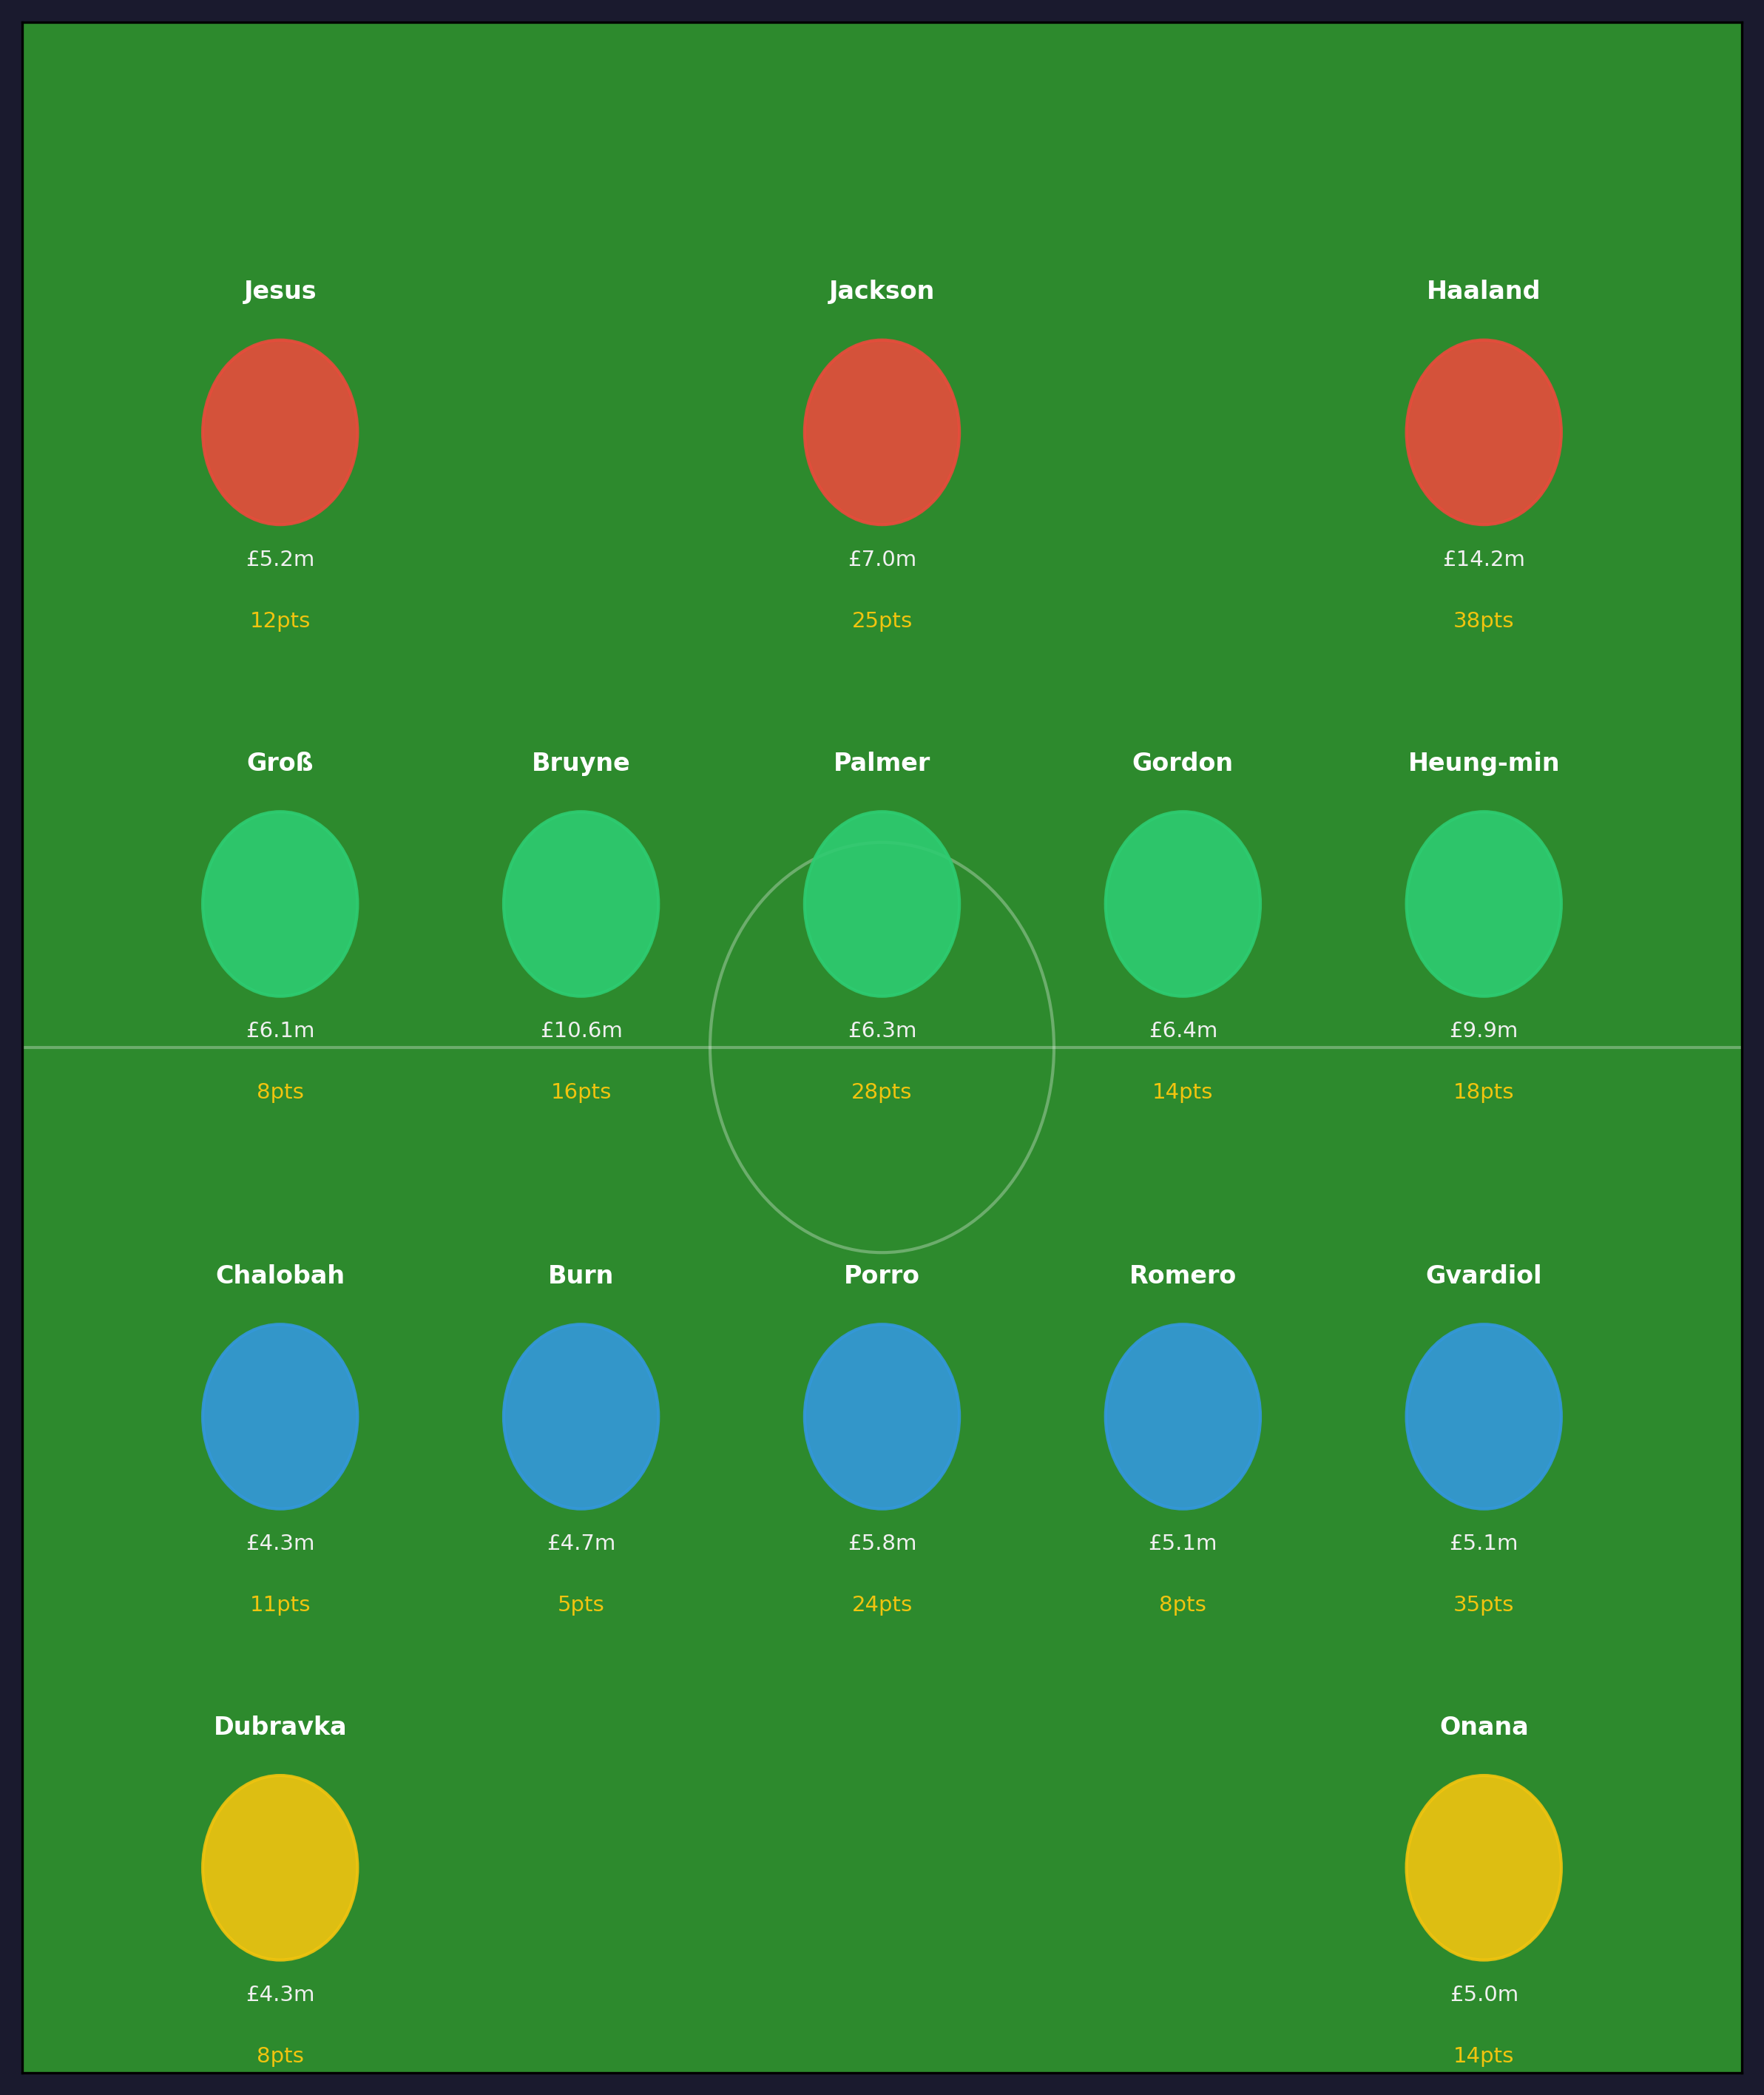

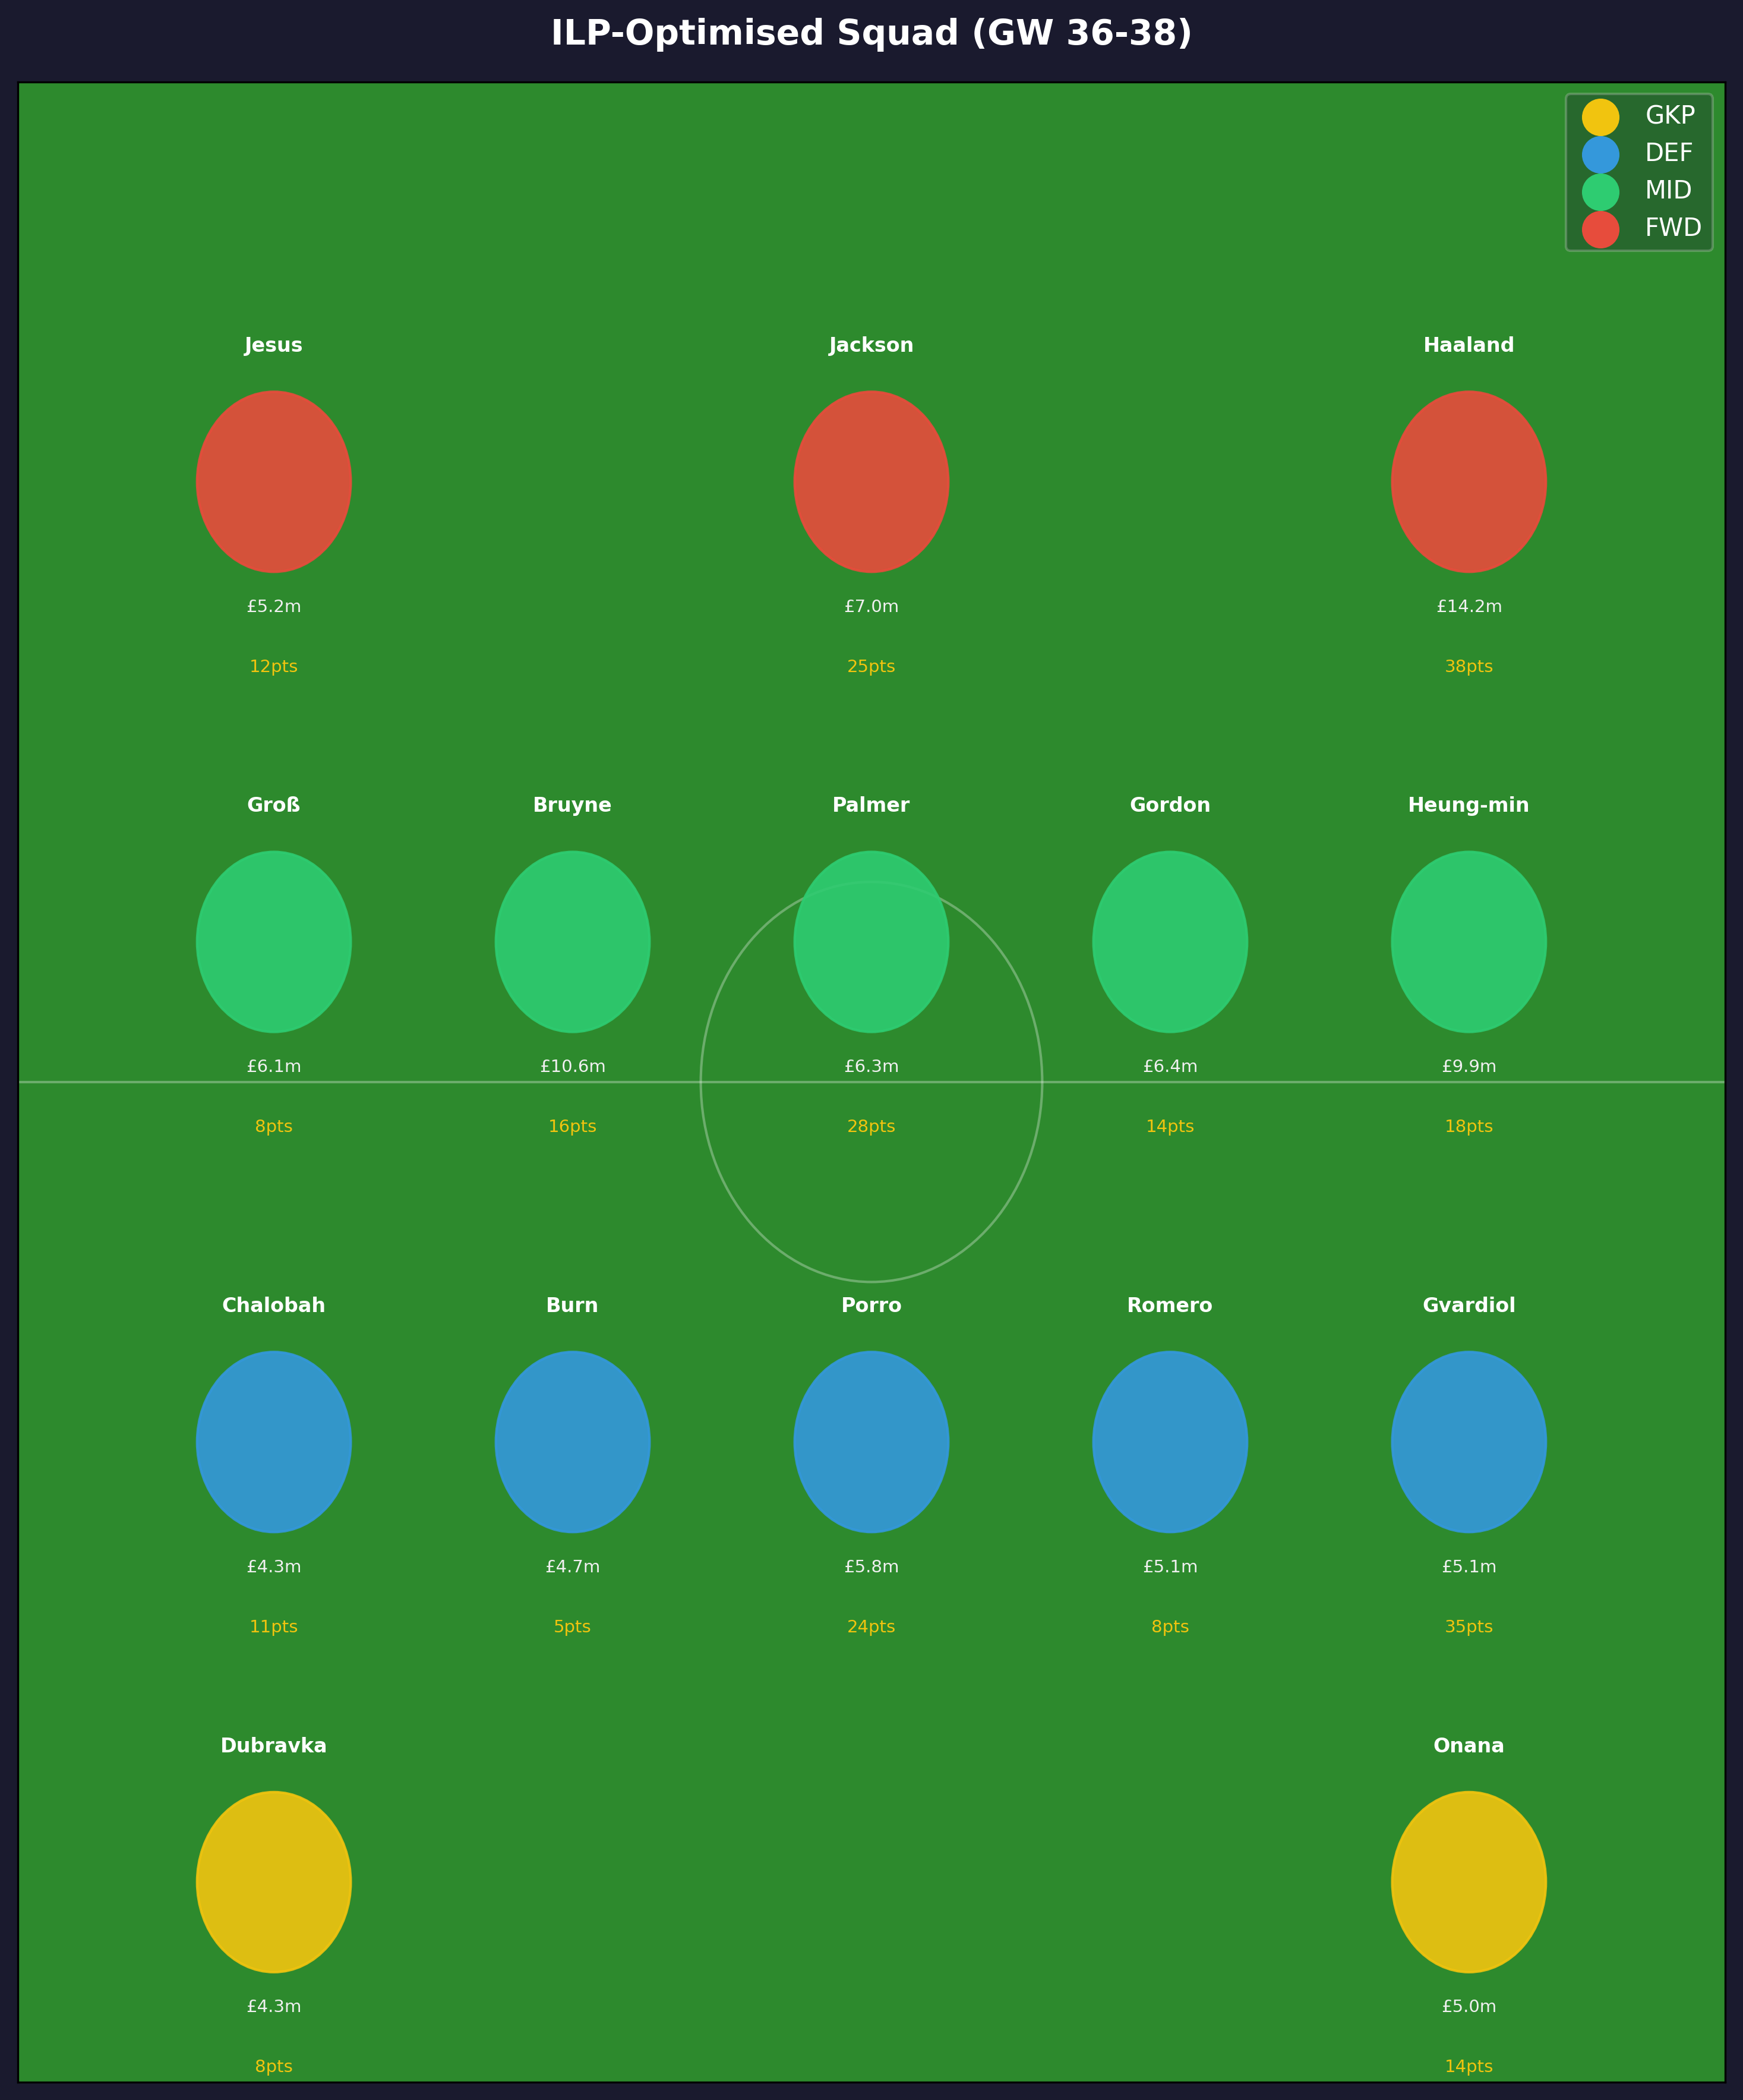

Squad figure saved.


In [25]:
# ── Plot 3: Squad on pitch (fixed) ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 12))
ax2.set_facecolor('#2d8a2d')
fig2.patch.set_facecolor('#1a1a2e')

# Pitch markings
ax2.plot([0,1],[0.5,0.5], 'white', alpha=0.3, linewidth=1)
circle = plt.Circle((0.5, 0.5), 0.1, color='white', fill=False, alpha=0.3, linewidth=1)
ax2.add_patch(circle)

pos_order  = {'GKP': 0.1, 'DEF': 0.32, 'MID': 0.57, 'FWD': 0.80}
pos_colors = {'GKP': '#f1c40f', 'DEF': '#3498db', 'MID': '#2ecc71', 'FWD': '#e74c3c'}

squad_display = ml_squad_gw.copy()
squad_display['position'] = squad_display['position'].replace('GK','GKP')

for pos, grp in squad_display.groupby('position'):
    y = pos_order.get(pos, 0.5)
    n = len(grp)
    x_positions = np.linspace(0.15, 0.85, n)
    for x_pos, (_, row) in zip(x_positions, grp.iterrows()):
        circ = plt.Circle((x_pos, y), 0.045,
                           color=pos_colors.get(pos,'white'), zorder=3, alpha=0.9)
        ax2.add_patch(circ)
        name_short = str(row['name']).split()[-1][:10]
        ax2.text(x_pos, y+0.065, name_short,
                 ha='center', fontsize=8, fontweight='bold', color='white', zorder=4)
        ax2.text(x_pos, y-0.065, f"£{row['price']:.1f}m",
                 ha='center', fontsize=7, color='#f0f0f0', zorder=4)
        ax2.text(x_pos, y-0.095, f"{row['cumulative_actual']:.0f}pts",
                 ha='center', fontsize=7, color='#f1c40f', zorder=4)

# Legend using scatter instead of patches
for pos, col in pos_colors.items():
    ax2.scatter([], [], color=col, label=pos, s=200)
ax2.legend(loc='upper right', fontsize=10, framealpha=0.3,
           facecolor='#1a1a2e', labelcolor='white')

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_title('ILP-Optimised Squad (GW 36-38)', color='white',
              fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../data/processed/poster_squad.png', dpi=300,
            bbox_inches='tight', facecolor=fig2.get_facecolor())
plt.show()
print('Squad figure saved.')

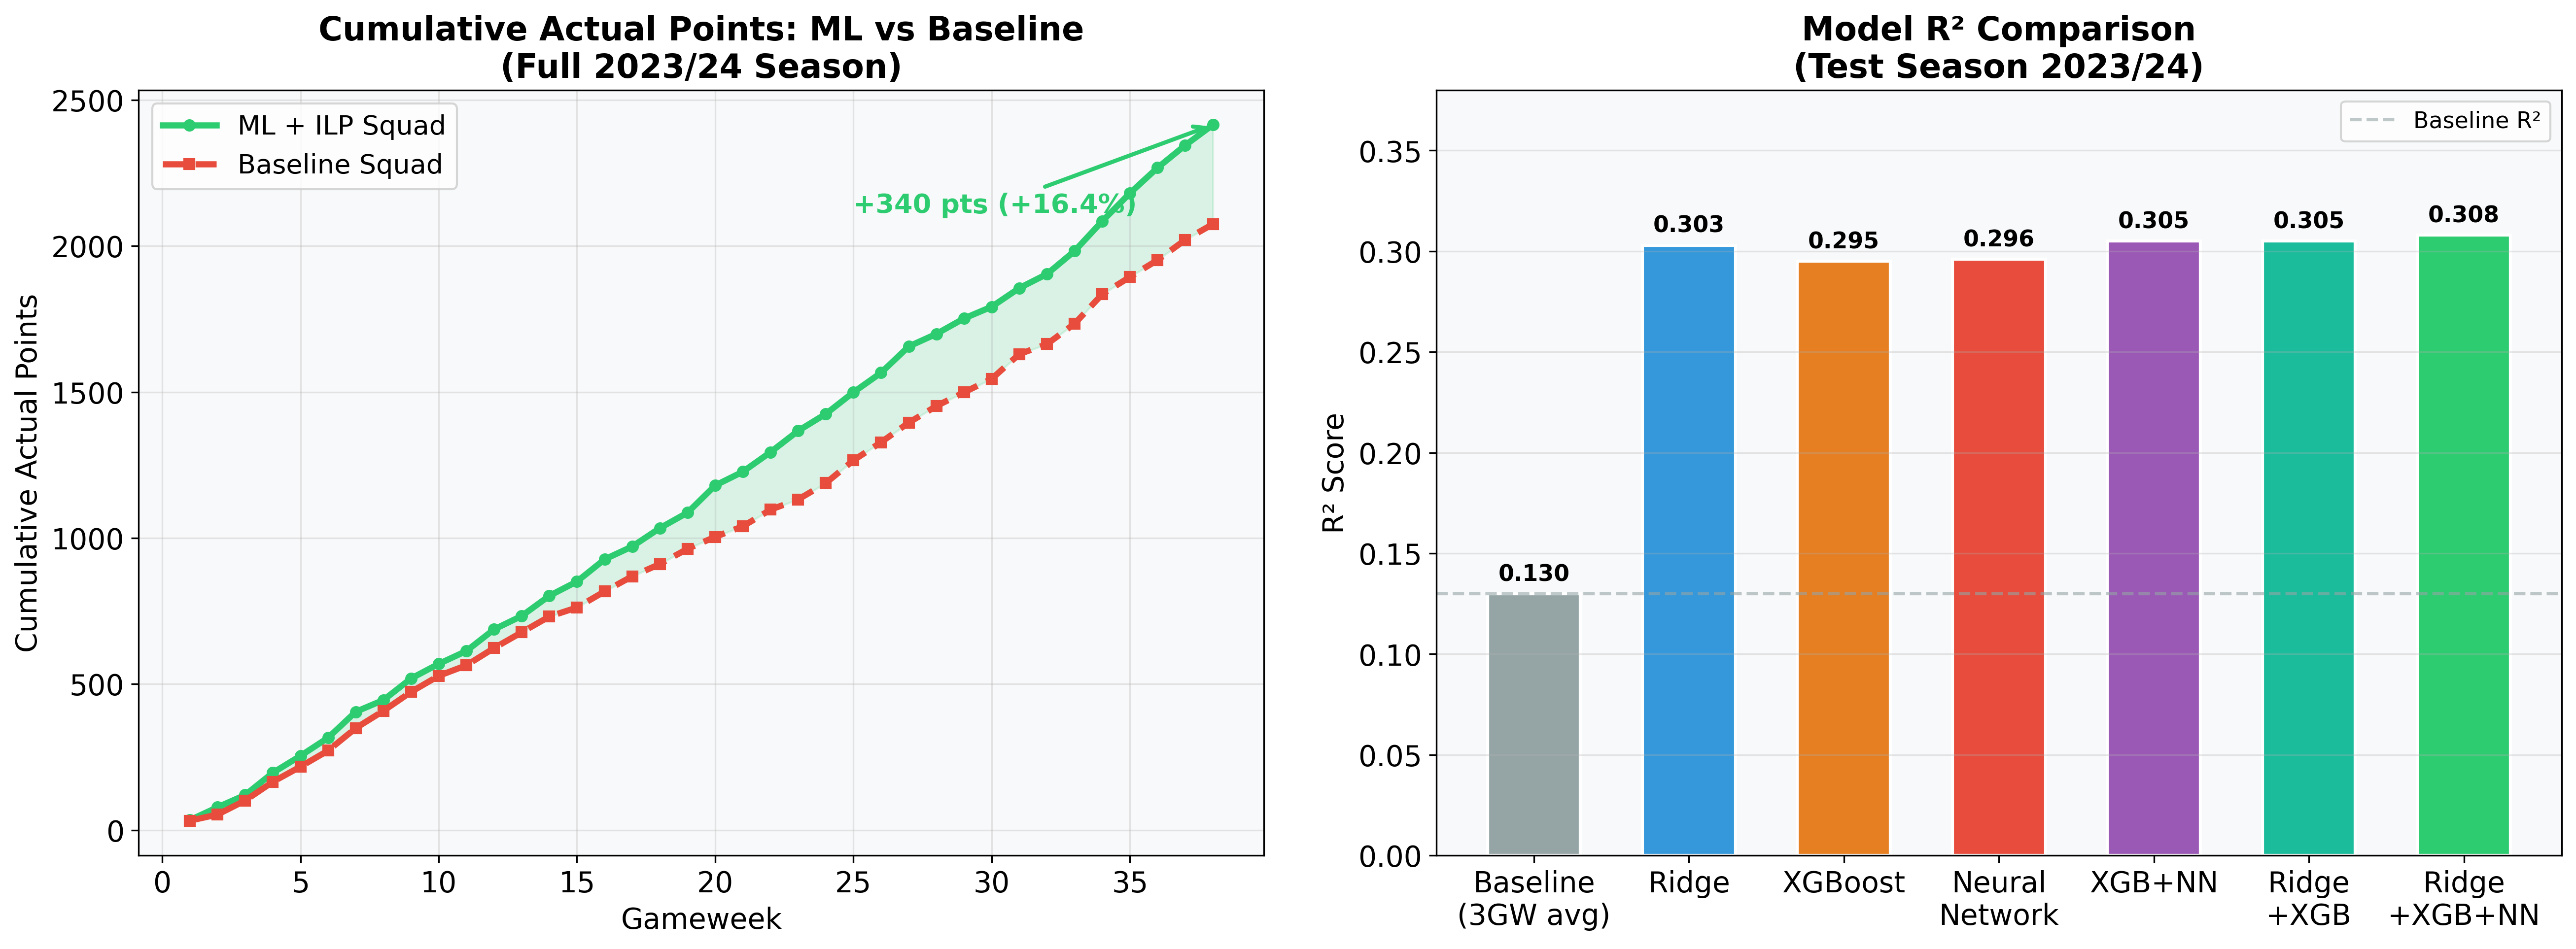

poster_fig1.png saved.


In [26]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'figure.dpi': 300
})

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Plot 1: Cumulative points line chart ──────────────────────────────
gw_df_plot = pd.DataFrame(gw_results_v2)
gw_df_plot['ml_cumulative']   = gw_df_plot['ml_pts'].cumsum()
gw_df_plot['base_cumulative'] = gw_df_plot['base_pts'].cumsum()

axes[0].plot(gw_df_plot['GW'], gw_df_plot['ml_cumulative'],
             color='#2ecc71', linewidth=3, marker='o', markersize=5,
             label='ML + ILP Squad')
axes[0].plot(gw_df_plot['GW'], gw_df_plot['base_cumulative'],
             color='#e74c3c', linewidth=3, marker='s', markersize=5,
             linestyle='--', label='Baseline Squad')
axes[0].fill_between(gw_df_plot['GW'],
                      gw_df_plot['ml_cumulative'],
                      gw_df_plot['base_cumulative'],
                      alpha=0.15, color='#2ecc71')
axes[0].set_title('Cumulative Actual Points: ML vs Baseline\n(Full 2023/24 Season)', fontweight='bold')
axes[0].set_xlabel('Gameweek')
axes[0].set_ylabel('Cumulative Actual Points')
axes[0].legend(fontsize=13)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(alpha=0.3)
axes[0].annotate(f'+340 pts (+16.4%)',
                  xy=(38, gw_df_plot['ml_cumulative'].iloc[-1]),
                  xytext=(25, gw_df_plot['ml_cumulative'].iloc[-1] - 300),
                  fontsize=13, fontweight='bold', color='#2ecc71',
                  arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2))

# ── Plot 2: Model R² bar chart ────────────────────────────────────────
models = ['Baseline\n(3GW avg)', 'Ridge', 'XGBoost', 'Neural\nNetwork',
          'XGB+NN', 'Ridge\n+XGB', 'Ridge\n+XGB+NN']
r2_vals = [0.130, 0.303, 0.295, 0.296, 0.305, 0.305, 0.308]
colors  = ['#95a5a6','#3498db','#e67e22','#e74c3c',
           '#9b59b6','#1abc9c','#2ecc71']

bars = axes[1].bar(models, r2_vals, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.6)
axes[1].set_title('Model R² Comparison\n(Test Season 2023/24)', fontweight='bold')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 0.38)
axes[1].axhline(y=0.130, color='#95a5a6', linestyle='--',
                alpha=0.6, label='Baseline R²')
for bar, val in zip(bars, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=11, fontweight='bold')
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout(pad=2)
plt.savefig('../data/processed/poster_fig1.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print('poster_fig1.png saved.')